# Notebook 4: Naive RAG vs Graph RAG

In this notebook, I implement two different RAG pipelines over the same MIT OpenCourseWare dataset and compare their answers on the same questions.

**Naive RAG** retrieves courses by hybrid search (BM25 + vector), then passes full course records as flat text to the LLM. Each record includes title, description, topics, instructors, and year.

**Graph RAG** takes a different approach:

- **Route first, search second:** A query router classifies each question. Known patterns (instructor lookup, recent courses by topic, etc.) trigger targeted Cypher templates that query the graph directly. In this case, no hybrid search is involved.

    - **When templates match:** The LLM gets precise graph query results, e.g., all courses by that instructor, all recent courses on cognitive science, all courses sharing an instructor with _Introduction to Machine Learning_, plus enrichment information (e.g., topic hierarchy, co-occurring topics, and neighboring courses).

    - **When they don't match:** Fallback to the same hybrid search as naive RAG, then enrich those results with graph context.

The questions reflect realistic user queries: asking about an instructor's courses, finding the latest offerings on a topic, or exploring connections between fields. These questions naturally involve relationships, filtering, and hierarchy, where structured context often makes a difference.

---
## Setup

In [1]:
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

import re
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image, display

import anthropic
from dotenv import load_dotenv
from neo4j import GraphDatabase
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

load_dotenv(dotenv_path='../.env')
PROJECT_ROOT = Path('..')

pd.set_option('display.max_colwidth', None)

In [2]:
# Neo4j
NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD', '')

if not NEO4J_PASSWORD:
    raise ValueError('NEO4J_PASSWORD not set.')

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as session:
    result = session.run('RETURN 1 AS connected')
    print(f'Neo4j connected: {result.single()["connected"] == 1}')

Neo4j connected: True


In [3]:
# LLM client with retry on overload
ANTHROPIC_API_KEY = os.getenv('ANTHROPIC_API_KEY', '')

if not ANTHROPIC_API_KEY:
    raise ValueError('ANTHROPIC_API_KEY not set.')

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
MODEL = 'claude-sonnet-4-20250514'


def call_llm(system, user_content, max_tokens=1024, max_retries=3):
    '''Call Claude with retry on overload errors.'''
    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL,
                max_tokens=max_tokens,
                temperature=0,
                system=system,
                messages=[{'role': 'user', 'content': user_content}]
            )
            return response.content[0].text.strip()
        except anthropic.APIStatusError as e:
            if e.status_code == 529 and attempt < max_retries - 1:
                wait = 2 ** attempt * 5
                print(f'  API overloaded, retrying in {wait}s...')
                time.sleep(wait)
            else:
                raise


print('LLM client ready')

LLM client ready


**Model choice:** I selected Claude Sonnet 4 because of its ability to follow instructions well and present structured output. These capabilities are critical for the query router, which must return valid JSON, and for Cypher generation, which must produce syntactically correct queries. Larger models like Claude Opus would offer stronger reasoning, but at higher cost and latency. In smaller models, the risk of unreliable structured output is higher, especially for the router's JSON classification task.

In [4]:
embedder = SentenceTransformer('BAAI/bge-small-en-v1.5')
EMBEDDING_DIM = 384
print(f'Embedder loaded (dim={EMBEDDING_DIM})')

Embedder loaded (dim=384)


**Embedding model choice:** BGE-small-en-v1.5 is a compact sentence embedding model with 33M parameters and 384 dimensions. This model ranks well on retrieval benchmarks relative to its size. A larger model would add latency and probably wouldn't provide meaningful quality gains for this particular project.

---
## Load data and build indexes

The course data is loaded from the CSV file. Both pipelines use the same data, the same embeddings, the same BM25 index, and the same hybrid search function.

In [5]:
# Load course data from CSV
csv_df = pd.read_csv(PROJECT_ROOT / 'data' / 'curated' / 'courses.csv')

csv_courses = []
for _, row in csv_df.iterrows():
    csv_courses.append({
        'title': row['title'],
        'description': row['description'],
        'course_number': row['course_number'],
        'year': int(row['year']),
        'topics': row['topics'],
        'instructors': row['instructors'],
    })

print(f'{len(csv_courses)} courses loaded from CSV')

# Preview
c = csv_courses[0]
for k, v in c.items():
    v_str = str(v)
    print(f'  {k}: {v_str[:80] + "..." if len(v_str) > 80 else v_str}')

50 courses loaded from CSV
  title: Advances in Computer Vision
  description: This course dives into advanced concepts in computer vision. A first focus is ge...
  course_number: 6-8300
  year: 2025
  topics: Data Science, Analytics & Computer Technology; AI; Machine Learning; Computer Sc...
  instructors: Prof. Vincent Sitzmann


In [6]:
# Build embeddings
enriched_texts = [
    f'{c["title"]} | {c["topics"]} | {c["description"]}'
    for c in csv_courses
]
embeddings = embedder.encode(enriched_texts, normalize_embeddings=True)
print(f'Embedded {embeddings.shape[0]} courses')

Embedded 50 courses


In [7]:
# BM25 index over titles, descriptions, and topics
def tokenize(text):
    '''Regex tokenization: split on word boundaries, lowercase.'''
    return re.findall(r'\b\w+\b', text.lower())

tokenized_corpus = [
    tokenize(f'{c["title"]} {c["topics"]} {c["description"]}')
    for c in csv_courses
]
bm25 = BM25Okapi(tokenized_corpus)
print(f'BM25 index built ({len(tokenized_corpus)} documents)')

BM25 index built (50 documents)


---
## Shared retrieval

Both pipelines leverage a unified hybrid search function to ensure robust context retrieval:

* **Hybrid Search:** Combines BM25 for precise keyword matching with Vector search for semantic similarity.
* **Reciprocal Rank Fusion (RRF):** Merges these distinct result sets into a single, re-ranked list to prioritize the most relevant documents.

In [8]:
def keyword_search(query, top_k=10):
    '''BM25 search over course titles, topics, and descriptions.'''
    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    top_idx = np.argsort(scores)[::-1][:top_k]
    return [(csv_courses[i]['title'], float(scores[i])) for i in top_idx if scores[i] > 0]


def vector_search(query, top_k=10):
    '''Cosine similarity search over course embeddings.'''
    query_emb = embedder.encode(query, normalize_embeddings=True)
    scores = embeddings @ query_emb
    top_idx = np.argsort(scores)[::-1][:top_k]
    return [(csv_courses[i]['title'], float(scores[i])) for i in top_idx]


def hybrid_search(query, top_k=5):
    '''Reciprocal rank fusion of BM25 + vector search.'''
    kw = keyword_search(query, top_k=top_k * 2)
    vec = vector_search(query, top_k=top_k * 2)

    RRF_K = 60
    scores = {}
    for rank, (title, _) in enumerate(kw):
        scores[title] = scores.get(title, 0) + 1 / (RRF_K + rank + 1)
    for rank, (title, _) in enumerate(vec):
        scores[title] = scores.get(title, 0) + 1 / (RRF_K + rank + 1)

    ranked = sorted(scores.keys(), key=lambda t: scores[t], reverse=True)
    return ranked[:top_k]

In [9]:
# Quick test
for t in hybrid_search('deep learning and neural networks'):
    print(f'  {t}')

  Hands-on Deep Learning
  Deep Learning
  Advances in Computer Vision
  Machine Learning
  Machine Learning for Inverse Graphics


---
## Naive RAG pipeline

Hybrid search retrieves courses. The LLM receives full course records as flat text: title, description, topics, instructors, year, and course number.

In [10]:
NAIVE_SYSTEM_PROMPT = '''You are a helpful assistant answering questions about
MIT OpenCourseWare courses.

You receive course records with title, description, topics, instructors,
year, and course number. Answer based only on this information.

If the information is insufficient, say so. Do not invent.'''


def build_flat_context(titles):
    '''Build flat text from course titles.'''
    courses = [c for c in csv_courses if c['title'] in titles]
    parts = []
    for c in courses:
        parts.append(
            f'Title: {c["title"]}\n'
            f'Course number: {c["course_number"]}\n'
            f'Year: {c["year"]}\n'
            f'Topics: {c["topics"]}\n'
            f'Instructors: {c["instructors"]}\n'
            f'Description: {c["description"]}'
        )
    return '\n\n---\n\n'.join(parts)


def naive_rag(question, top_k=5):
    '''Naive RAG: hybrid search -> flat text -> LLM answer.'''
    titles = hybrid_search(question, top_k=top_k)
    context = build_flat_context(titles)

    answer = call_llm(
        NAIVE_SYSTEM_PROMPT,
        f'Question: {question}\n\nRetrieved courses:\n\n{context}'
    )

    return {
        'question': question,
        'retrieved': titles,
        'answer': answer,
        'pipeline': 'naive_rag'
    }

---

## Graph RAG pipeline

Our Graph RAG system uses predefined Cypher templates for question types that map to known graph patterns. This template-based approach offers two key advantages:

- **Enhanced accuracy**: Deterministic results for common question types
- **Lower latency**: Queries the graph directly instead of using hybrid search

An LLM-based router classifies each question and selects the right template. When a template matches, Graph RAG bypasses hybrid search entirely and queries the graph directly. When no template matches or the template returns empty results, the system falls back to the shared hybrid search with graph enrichment.

The current set of templates can be later expanded based on the most frequent questions asked by users, ensuring the system continuously improves to handle common queries.

### Prompt engineering

The LLM is called in three roles across this pipeline: as a query router, as a Cypher generator, and as an answer generator. Each role uses a different prompt, but all share a set of common practices:

**Grounding and constraint:** Every system prompt tells the LLM to answer based only on the provided context and to say so when information is insufficient. This reduces hallucination by making the LLM's scope explicit.

**Structured output control:** The router prompt specifies the exact JSON format expected, uses few-shot examples (one per category) with the precise parameter keys, and restricts the output to JSON only (no explanation, no markdown, no backticks). This makes the output more reliably parseable.

**Schema-aware generation:** The Cypher fallback prompt includes the full graph schema (node labels, properties, and relationship types), so the LLM generates queries against the actual data model rather than guessing at structure.

**Self-correction:** When a generated Cypher query fails, the error message is fed back to the LLM with a request to fix it, up to two retries. This handles syntax errors and invalid property references without manual intervention.

**Deterministic output:** All LLM calls use `temperature=0` to minimize randomness and hallucination risk in routing decisions, Cypher generation, and answer formulation.

**Role separation:** System prompts define behavior and constraints. User messages provide the question and the retrieved context. This follows the standard practice of keeping instructions stable across calls while varying only the input.

### Traversal templates

In [11]:
MIN_RELATED_WEIGHT = 3


def template_instructor_lookup(instructor_name):
    '''Find all courses by an instructor via TAUGHT_BY.'''
    if not instructor_name or len(instructor_name) < 3:
        return []
    result = driver.execute_query('''
        MATCH (c:Course)-[:TAUGHT_BY]->(i:Instructor)
        WHERE toLower(i.name) CONTAINS toLower($name)
        WITH DISTINCT c, i
        OPTIONAL MATCH (c)-[:HAS_TOPIC]->(t:Topic)
        WITH c, i, collect(DISTINCT t.name) AS topics
        RETURN c.title AS title, c.description AS description,
               c.year AS year, i.name AS instructor, topics
        ORDER BY c.year DESC
    ''', name=instructor_name)
    return [dict(r) for r in result.records]


def template_recent_by_topic(topic_name, limit=5):
    '''Find most recent courses on a topic, sorted by year.'''
    if not topic_name or len(topic_name) < 2:
        return []
    result = driver.execute_query('''
        MATCH (c:Course)-[:HAS_TOPIC]->(t:Topic)
        WHERE toLower(t.name) CONTAINS toLower($topic)
        OPTIONAL MATCH (c)-[:TAUGHT_BY]->(i:Instructor)
        WITH c, t, collect(DISTINCT i.name) AS instructors
        RETURN c.title AS title, c.description AS description,
               c.year AS year, t.name AS topic, instructors
        ORDER BY c.year DESC LIMIT $limit
    ''', topic=topic_name, limit=limit)
    return [dict(r) for r in result.records]


def template_cross_domain(parent_a, parent_b):
    '''Find courses bridging two parent categories via CHILD_OF.'''
    if not parent_a or not parent_b:
        return []
    result = driver.execute_query('''
        MATCH (c:Course)-[:HAS_TOPIC]->(t1:Topic)-[:CHILD_OF]->(p1:Topic)
        WHERE toLower(p1.name) = toLower($parent_a)
        WITH c, t1, p1
        MATCH (c)-[:HAS_TOPIC]->(t2:Topic)-[:CHILD_OF]->(p2:Topic)
        WHERE toLower(p2.name) = toLower($parent_b)
          AND p1 <> p2
        WITH DISTINCT c, collect(DISTINCT t1.name) AS topics_a, collect(DISTINCT t2.name) AS topics_b
        OPTIONAL MATCH (c)-[:TAUGHT_BY]->(i:Instructor)
        RETURN c.title AS title, c.description AS description, c.year AS year,
               topics_a AS topics_from_a, topics_b AS topics_from_b,
               collect(DISTINCT i.name) AS instructors
    ''', parent_a=parent_a, parent_b=parent_b)
    return [dict(r) for r in result.records]


def template_related_courses(course_title):
    '''Find related courses ranked by shared child-level topics.'''
    if not course_title:
        return []
    result = driver.execute_query('''
        MATCH (c:Course {title: $title})-[:HAS_TOPIC]->(t:Topic {level: 'child'})
        WITH c, collect(t) AS source_topics
        UNWIND source_topics AS t
        MATCH (other:Course)-[:HAS_TOPIC]->(t)
        WHERE other <> c
        WITH other, count(DISTINCT t) AS shared
        WHERE shared >= 4
        OPTIONAL MATCH (other)-[:HAS_TOPIC]->(ot:Topic)
        OPTIONAL MATCH (other)-[:TAUGHT_BY]->(i:Instructor)
        RETURN other.title AS title, other.description AS description,
               other.year AS year, shared,
               collect(DISTINCT ot.name) AS topics,
               collect(DISTINCT i.name) AS instructors
        ORDER BY shared DESC
        LIMIT 10
    ''', title=course_title)
    return [dict(r) for r in result.records]


def template_shared_instructor(course_title):
    '''Find courses sharing an instructor with a given course.'''
    if not course_title:
        return []
    result = driver.execute_query('''
        MATCH (c:Course {title: $title})-[:TAUGHT_BY]->(i:Instructor)<-[:TAUGHT_BY]-(other:Course)
        WHERE other <> c
        WITH DISTINCT other, i
        OPTIONAL MATCH (other)-[:HAS_TOPIC]->(t:Topic)
        WITH other, i, collect(DISTINCT t.name) AS topics
        RETURN other.title AS title, other.description AS description,
               other.year AS year, i.name AS shared_instructor, topics
        ORDER BY other.year DESC
    ''', title=course_title)
    return [dict(r) for r in result.records]


def template_cooccurring_topics(topic_name):
    '''Find topics that co-occur with a given topic via RELATED_TO edges.'''
    if not topic_name or len(topic_name) < 2:
        return []
    result = driver.execute_query('''
        MATCH (t:Topic {level: 'child'})-[r:RELATED_TO]-(other:Topic)
        WHERE toLower(t.name) CONTAINS toLower($topic)
          AND r.weight >= $min_weight
        OPTIONAL MATCH (other)-[:CHILD_OF]->(parent:Topic)
        RETURN other.name AS topic, other.level AS level,
               parent.name AS parent, r.weight AS cooccurrences
        ORDER BY cooccurrences DESC
    ''', topic=topic_name, min_weight=2)
    return [dict(r) for r in result.records]

### Query router

In [12]:
ROUTER_PROMPT = '''Classify the following question about MIT OpenCourseWare courses.

Categories and expected JSON output:

- instructor_lookup: asking about courses taught by a specific instructor.
  Example: {"category": "instructor_lookup", "params": {"instructor": "Prof. Tom\u00e1s Lozano-P\u00e9rez"}}

- recent_by_topic: asking for the most recent/newest/latest courses on a topic.
  Example: {"category": "recent_by_topic", "params": {"topic": "Cognitive Science"}}

- cross_domain: asking for courses that bridge/combine two broad fields.
  Example: {"category": "cross_domain", "params": {"parent_a": "Engineering", "parent_b": "Social Sciences"}}
  Valid parent categories: Art, Design & Architecture | Business & Management | Data Science, Analytics & Computer Technology | Education & Teaching | Energy, Climate & Sustainability | Engineering | Health & Medicine | Humanities | Innovation & Entrepreneurship | Science & Math | Social Sciences.

- related_courses: asking for courses related or similar to a specific course.
  Example: {"category": "related_courses", "params": {"course_title": "Affective Computing"}}

- shared_instructor: asking which courses share an instructor with a given course.
  Example: {"category": "shared_instructor", "params": {"course_title": "Introduction to Machine Learning"}}

- cooccurring_topics: asking what topics are related to or co-occur with a given topic.
  Example: {"category": "cooccurring_topics", "params": {"topic": "Cognitive Science"}}

- general: none of the above.
  Example: {"category": "general", "params": {}}

Return ONLY a JSON object. No explanation, no markdown, no backticks.'''


def route_question(question, verbose=True):
    '''Classify question and run matching template.'''
    raw = call_llm(ROUTER_PROMPT, question, max_tokens=256)

    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        if verbose:
            print(f'  Router: invalid JSON')
        return None

    category = parsed.get('category', 'general')
    params = parsed.get('params', {})
    if verbose:
        print(f'  Router: {category} | {params}')

    templates = {
        'instructor_lookup': lambda p: template_instructor_lookup(p.get('instructor', '')),
        'recent_by_topic': lambda p: template_recent_by_topic(p.get('topic', '')),
        'cross_domain': lambda p: template_cross_domain(p.get('parent_a', ''), p.get('parent_b', '')),
        'related_courses': lambda p: template_related_courses(p.get('course_title', '')),
        'shared_instructor': lambda p: template_shared_instructor(p.get('course_title', '')),
        'cooccurring_topics': lambda p: template_cooccurring_topics(p.get('topic', '')),
    }

    if category in templates:
        results = templates[category](params)
        if results:
            return category, results
        return 'no_results', category, params

    return None

### Safe LLM Cypher fallback

The LLM Cypher fallback runs generated queries inside a **read-only** transaction (`session.execute_read`). This blocks any destructive query (`DELETE`, `CREATE`, etc.) from modifying the graph, since Neo4j simply won't execute it. The Cypher templates use standard `driver.execute_query` calls since they're hardcoded and safe by design.

In [13]:
SCHEMA = '''
Node labels and properties:
- Course: title, description, url, course_number, availability, year
- Topic: name, level ("parent" or "child")
- Instructor: name

Relationships:
- (Course)-[:HAS_TOPIC]->(Topic)
- (Course)-[:TAUGHT_BY]->(Instructor)
- (Topic {level: "child"})-[:CHILD_OF]->(Topic {level: "parent"})
- (Topic {level: "child"})-[:RELATED_TO {weight: Int}]->(Topic {level: "child"})

Notes: RELATED_TO is symmetric. 50 courses, 44 topics, 70 instructors.'''

CYPHER_PROMPT = f'''Generate a Cypher query for this Neo4j graph.
Return ONLY the query. No explanation, no backticks.
{SCHEMA}'''


def llm_cypher_fallback(question, max_retries=2, verbose=True):
    '''Generate and run Cypher via LLM. Read-only to prevent accidental writes.'''
    cypher = call_llm(CYPHER_PROMPT, question)
    if verbose:
        print(f'  Cypher: {cypher[:100]}')

    for attempt in range(max_retries + 1):
        try:
            with driver.session() as session:
                result = session.execute_read(
                    lambda tx: list(tx.run(cypher))
                )
            return cypher, [dict(r) for r in result]
        except Exception as e:
            if attempt < max_retries:
                error_msg = f'Query failed:\n{cypher}\nError: {e}\nFix it.'
                cypher = call_llm(CYPHER_PROMPT, error_msg)
            else:
                return cypher, []
    return cypher, []

### Graph enrichment and full pipeline

In [14]:
def enrich_with_graph(titles):
    '''Add structured graph context to retrieved courses.'''
    if not titles:
        return {'courses': [], 'related_topics': [], 'neighboring_courses': []}

    result = driver.execute_query('''
        MATCH (c:Course) WHERE c.title IN $titles
        OPTIONAL MATCH (c)-[:HAS_TOPIC]->(t:Topic)
        OPTIONAL MATCH (c)-[:TAUGHT_BY]->(i:Instructor)
        OPTIONAL MATCH (t)-[:CHILD_OF]->(parent:Topic)
        WITH c,
             collect(DISTINCT {name: t.name, level: t.level, parent: parent.name}) AS topics,
             collect(DISTINCT i.name) AS instructors
        RETURN c.title AS title, c.description AS description, c.year AS year,
               topics, instructors
    ''', titles=titles)
    courses = [dict(r) for r in result.records]

    result = driver.execute_query('''
        MATCH (c:Course) WHERE c.title IN $titles
        MATCH (c)-[:HAS_TOPIC]->(t:Topic)-[rel:RELATED_TO]-(related:Topic)
        WHERE rel.weight >= $w AND NOT (c)-[:HAS_TOPIC]->(related)
        RETURN DISTINCT related.name AS topic, rel.weight AS weight
        ORDER BY weight DESC LIMIT 10
    ''', titles=titles, w=MIN_RELATED_WEIGHT)
    related = [dict(r) for r in result.records]

    result = driver.execute_query('''
        MATCH (c:Course) WHERE c.title IN $titles
        MATCH (c)-[:HAS_TOPIC]->(t:Topic)-[rel:RELATED_TO]-(rt:Topic)<-[:HAS_TOPIC]-(other:Course)
        WHERE NOT other.title IN $titles AND rel.weight >= $w
        WITH other, count(DISTINCT rt) AS shared
        RETURN other.title AS title, shared ORDER BY shared DESC LIMIT 5
    ''', titles=titles, w=MIN_RELATED_WEIGHT)
    neighbors = [dict(r) for r in result.records]

    return {'courses': courses, 'related_topics': related, 'neighboring_courses': neighbors}

In [15]:
GRAPH_SYSTEM_PROMPT = '''You are a helpful assistant answering questions about
MIT OpenCourseWare courses using knowledge graph results.

You receive structured context with courses, topics (in parent/child
hierarchy), instructors, co-occurring topics, and neighboring courses.
Give clear, specific answers. If results are insufficient, say so.'''


def graph_rag(question, top_k=5, verbose=True):
    '''Graph RAG: route -> template or shared hybrid search -> enrich -> LLM.'''
    route_result = route_question(question, verbose=verbose)

    # Template matched and returned results
    if route_result and isinstance(route_result, tuple) and len(route_result) == 2:
        template_name, template_results = route_result
        titles = [r.get('title', '') for r in template_results if r.get('title')]
        titles = list(dict.fromkeys(titles))
        context_data = template_results
        method = f'template:{template_name}'

    # Template matched but returned empty -> LLM Cypher as fallback
    elif route_result and isinstance(route_result, tuple) and route_result[0] == 'no_results':
        _, category, params = route_result
        cypher, llm_results = llm_cypher_fallback(question, verbose=verbose)
        titles = [r.get('title', '') for r in llm_results if r.get('title')]
        titles = list(dict.fromkeys(titles))
        context_data = llm_results
        method = f'llm_cypher (from {category})'

    # No template matched (general) -> hybrid search with graph enrichment
    else:
        titles = hybrid_search(question, top_k=top_k)
        context_data = [c for c in csv_courses if c['title'] in titles]
        method = 'hybrid_fallback'

    # Enrich with graph context
    enrichment = enrich_with_graph(titles) if titles else {
        'courses': [], 'related_topics': [], 'neighboring_courses': []}

    full_context = {'query_results': context_data, 'enrichment': enrichment}
    context_str = json.dumps(full_context, indent=2, default=str)

    answer = call_llm(
        GRAPH_SYSTEM_PROMPT,
        f'Question: {question}\n\nKnowledge graph context:\n{context_str}'
    )

    return {
        'question': question,
        'method': method,
        'retrieved_titles': titles,
        'answer': answer,
        'pipeline': 'graph_rag'
    }

---
## Test questions

Each question targets a different type of reasoning. Both pipelines have the same underlying data (title, description, topics, instructors, and year) and use the same retrieval function.

| # | Type | Challenge for flat text |
|---|---|---|
| 1 | Instructor traversal | Must connect an instructor name across multiple records |
| 2 | Recency + filtering | Must filter by topic AND sort by year |
| 3 | Multi-hop (shared instructor) | Must find a course, its instructors, then their other courses |
| 4 | Co-occurrence | Must aggregate topic co-occurrence across the entire corpus |
| 5 | Indirect relationship | Must trace from a course through shared topics to other courses |
| 6 | Semantic search | Broad thematic query with no structural shortcut |

In [16]:
test_questions = [
    'What courses does Prof. Tom\u00e1s Lozano-P\u00e9rez teach besides Introduction to Machine Learning?',
    'What are the most recent courses on cognitive science?',
    'Which courses share an instructor with Introduction to Machine Learning?',
    'What topics co-occur most frequently with cognitive science?',
    'What courses are related to Affective Computing?',
    'What courses discuss the societal impact of technology?',
]

---
## Run both pipelines

In [17]:
results_naive = []
results_graph = []

for i, q in enumerate(test_questions):
    print(f'Q{i+1}: {q}')
    rn = naive_rag(q)
    rg = graph_rag(q, verbose=False)
    results_naive.append(rn)
    results_graph.append(rg)
    print(f'  -> graph method: {rg["method"]}')
    print()

print('Done')

Q1: What courses does Prof. Tomás Lozano-Pérez teach besides Introduction to Machine Learning?
  -> graph method: template:instructor_lookup

Q2: What are the most recent courses on cognitive science?
  -> graph method: template:recent_by_topic

Q3: Which courses share an instructor with Introduction to Machine Learning?
  -> graph method: template:shared_instructor

Q4: What topics co-occur most frequently with cognitive science?
  -> graph method: template:cooccurring_topics

Q5: What courses are related to Affective Computing?
  -> graph method: template:related_courses

Q6: What courses discuss the societal impact of technology?
  -> graph method: hybrid_fallback

Done


---
## Results

### Full answers

Complete answers from both pipelines are saved to a JSON file for detailed review.

In [18]:
all_results = []
for naive, graph in zip(results_naive, results_graph):
    all_results.append({
        'question': naive['question'],
        'naive_retrieved': naive['retrieved'],
        'naive_answer': naive['answer'],
        'graph_method': graph['method'],
        'graph_retrieved': graph['retrieved_titles'],
        'graph_answer': graph['answer'],
    })

results_path = PROJECT_ROOT / 'data' / 'curated' / 'rag_comparison_results.json'
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'Full results saved to {results_path}')

Full results saved to ..\data\curated\rag_comparison_results.json


### Ground truth verification

To measure performance objectively, I designed a golden dataset (`ground_truth.json`) with the expected answers for every test query. This curated ground truth allows us to calculate retrieval recall for both pipelines, checking if they retrieved the right courses required to answer the question.

In [19]:
# Load ground truth
gt_path = PROJECT_ROOT / 'data' / 'curated' / 'ground_truth.json'
with open(gt_path) as f:
    ground_truth = json.load(f)

print('Ground truth verification')
print()

eval_rows = []
for question, gt in ground_truth.items():
    q_idx = next((j for j, q in enumerate(test_questions) if q == question), None)
    if q_idx is None:
        continue
    q_num = q_idx + 1
    truth = gt['answer']

    naive_matches = [r for r in results_naive if r['question'] == question]
    graph_matches = [r for r in results_graph if r['question'] == question]
    if not naive_matches or not graph_matches:
        continue

    naive_r = naive_matches[0]
    graph_r = graph_matches[0]

    if gt['type'] == 'course_list':
        naive_hits = set(naive_r['retrieved']) & set(truth)
        graph_hits = set(graph_r['retrieved_titles']) & set(truth)
    elif gt['type'] == 'topic_list':
        gt_topics = {t['topic'] for t in truth}
        naive_hits = {t for t in gt_topics if t in naive_r['answer']}
        graph_hits = {t for t in gt_topics if t in graph_r['answer']}
        truth = list(gt_topics)

    print(f'Q{q_num}: {question}')
    print(f'  Ground truth ({len(truth)}): {"; ".join(str(t) for t in truth)}')
    print(f'  Naive RAG:  {len(naive_hits)}/{len(truth)}')
    print(f'  Graph RAG:  {len(graph_hits)}/{len(truth)}')
    print()

    eval_rows.append({
        '#': q_num,
        'question': question,
        'truth': len(truth),
        'naive_hits': len(naive_hits),
        'graph_hits': len(graph_hits),
        'naive_recall': f'{len(naive_hits)/len(truth):.0%}',
        'graph_recall': f'{len(graph_hits)/len(truth):.0%}',
    })

pd.DataFrame(eval_rows).set_index('#')

Ground truth verification

Q1: What courses does Prof. Tomás Lozano-Pérez teach besides Introduction to Machine Learning?
  Ground truth (2): Introduction to Electrical Engineering and Computer Science I; Techniques in Artificial Intelligence (SMA 5504)
  Naive RAG:  1/2
  Graph RAG:  2/2

Q2: What are the most recent courses on cognitive science?
  Ground truth (5): The Human Intelligence Enterprise; Affective Computing; Brains, Minds and Machines Summer Course; Minds and Machines; Principles of Autonomy and Decision Making
  Naive RAG:  2/5
  Graph RAG:  5/5

Q3: Which courses share an instructor with Introduction to Machine Learning?
  Ground truth (3): Introduction to Electrical Engineering and Computer Science I; Mobile Autonomous Systems Laboratory; Techniques in Artificial Intelligence (SMA 5504)
  Naive RAG:  0/3
  Graph RAG:  3/3

Q4: What topics co-occur most frequently with cognitive science?
  Ground truth (7): Mathematics; Psychology; Algorithms and Data Structures; Electr

,question,truth,naive_hits,graph_hits,naive_recall,graph_recall
#,,,,,,
1,What courses does Prof. Tomás Lozano-Pérez teach besides Introduction to Machine Learning?,2,1,2,50%,100%
2,What are the most recent courses on cognitive science?,5,2,5,40%,100%
3,Which courses share an instructor with Introduction to Machine Learning?,3,0,3,0%,100%
4,What topics co-occur most frequently with cognitive science?,7,4,7,57%,100%
5,What courses are related to Affective Computing?,10,1,10,10%,100%
6,What courses discuss the societal impact of technology?,12,3,3,25%,25%


### Qualitative assessment

| # | Question | Winner | Why |
|---|---|---|---|
| 1 | Other courses by Lozano-Pérez | **Graph RAG** | TAUGHT_BY traversal finds all courses directly; naive RAG retrieves by text similarity, not by instructor |
| 2 | Recent courses on cognitive science | **Graph RAG** | Explicitly filters by topic and sorts by `year` via Cypher; naive RAG has the data but struggles to filter and sort |
| 3 | Shared instructor with Intro to ML | **Graph RAG** | Two-hop traversal (course -> instructor -> courses); naive RAG must cross-reference instructor names across flat records |
| 4 | Topics co-occurring with cognitive science | **Graph RAG** | Pre-computed RELATED_TO weights give corpus-wide co-occurrence; naive RAG can only count from its retrieved records |
| 5 | Courses related to Affective Computing | **Graph RAG** | Counts shared child topics via HAS_TOPIC and ranks by overlap; naive RAG relies on text similarity |
| 6 | Societal impact of technology | **Tie** | No template matched; both pipelines used the same hybrid search and retrieved the same 3 of 12 ground truth courses |

### Discussion

The results show that the structured context derived from the graph improves LLM answers on questions that require structural reasoning. The queries about instructors (Q1 and Q3) are clear examples: Naive RAG can only identify instructor connections that happen to appear in the records that it retrieved by text similarity. Graph RAG, on the other hand, traverses TAUGHT_BY directly and finds all courses by that instructor regardless of text similarity.

The query about recent courses (Q2) tests more directly whether two different structures using the same data present distinct results. Both pipelines have the year field in every course record. However, Graph RAG filters by HAS_TOPIC and sorts by year in Cypher, while naive RAG retrieves by text similarity and asks the LLM to parse years from flat text and sort them.

The topic co-occurrence query (Q4) also leverages the ontology built in Notebook 3. Rather than recalculating co-occurrences at query time, Graph RAG reads the pre-computed RELATED_TO weights directly, giving the LLM precise, corpus-wide data. Naive RAG can only infer topic relationships from the handful of records it happened to retrieve.

The related courses query (Q5) tests whether the graph can find courses that share topics with a target course. The template counts how many child-level topics the target shares with every other course in the graph, then returns those with the highest overlap. Naive RAG retrieves 5 courses by text similarity, which may or may not share actual topics with the target. Increasing the retrieval window would likely bring in more courses with similar text, but also unrelated topics. Graph RAG's structural filter ensures that every returned course shares a minimum topic overlap with the target, so its results stay relevant as the set grows.

The query about societal impact (Q6) is a case where Graph RAG showed no advantage. No template matched this broad semantic question, so Graph RAG fell back to the same hybrid search as naive RAG. Both pipelines found 3 of 12 ground truth courses. This is expected: when a question depends on understanding descriptions rather than traversing relationships, the graph tends to add little or no value.

---
## Query performance

With 50 courses, query performance isn't a major concern. Nevertheless, profiling queries is a core practice when working with graph databases, so here is a quick demonstration using `PROFILE` on the instructor lookup template.

`PROFILE` executes the query and returns the execution plan, showing row counts and db hits at each step. The main information to look for is:
- Where the query anchors (its starting point)
- Whether it uses index scans vs full scans
- How many db hits each step produces

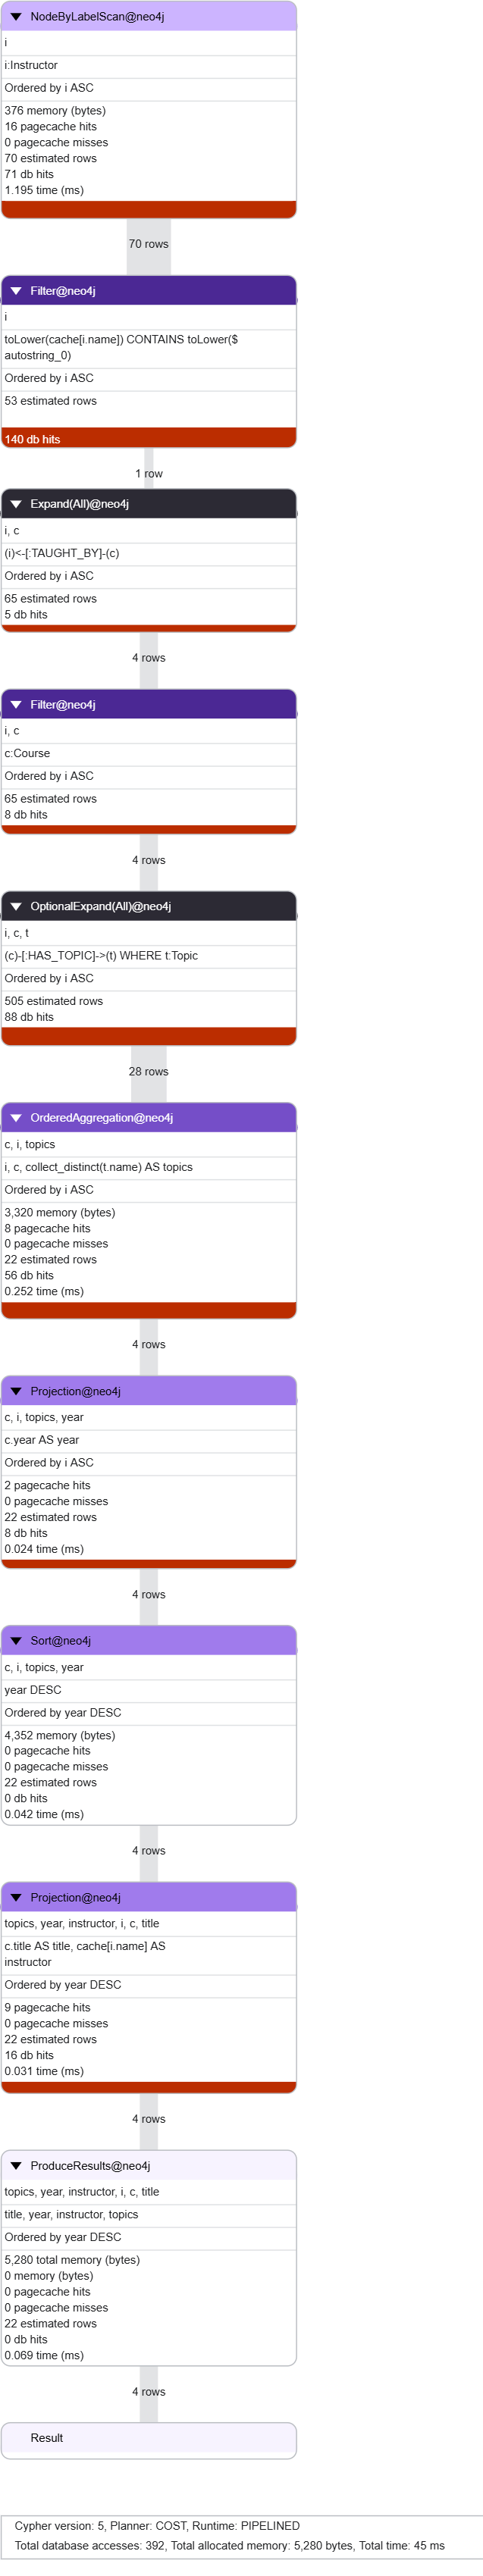

In [20]:
display(Image(filename=str(PROJECT_ROOT / 'figures' / 'query_plan_instructor_lookup.png'), width=500))

The plan reads top-down. The query anchors on `Instructor` nodes via a `NodeByLabelScan`, a full scan (not an index lookup) of all 70 Instructor nodes (71 db hits). It then filters by name (140 db hits for the `toLower` + `CONTAINS` check on each). Only 1 instructor passes the filter. From there it expands outward via TAUGHT_BY to find 4 courses (5 db hits), then optionally expands to their topics (88 db hits). Total: 392 db hits, in 45 ms.

At this scale, every step handles a small number of rows. In a production graph with thousands of courses, a major optimization step would be adding a text index on `Instructor.name` to replace the full scan with an index lookup. The `PROFILE` output guides these decisions by showing exactly where db hits accumulate. The goal is to minimize db hits, since each one represents a storage access that increases query latency.

---
## Close connections

In [21]:
driver.close()
print('Connection closed')

Connection closed


---
## Next Steps

In the next notebook, I apply graph algorithms (centrality, community detection, and similarity) to analyze the structure of the knowledge graph and discover patterns in the curriculum.